Note: To run this notebook, download training.csv and test.csv from Kaggle and place them in the /data folder.
https://www.kaggle.com/competitions/facial-keypoints-detection/data

In [265]:
import torch
import torch.utils.data as data
import torchvision.transforms.v2 as tfs
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [266]:
# read dataset

data_path = 'data/training.csv'

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    pd.set_option('display.max_columns', None)
    print(df.head())
else:
    print(f"File {data_path} does not exist. Please download it from Kaggle")


   left_eye_center_x  left_eye_center_y  right_eye_center_x  \
0          66.033564          39.002274           30.227008   
1          64.332936          34.970077           29.949277   
2          65.057053          34.909642           30.903789   
3          65.225739          37.261774           32.023096   
4          66.725301          39.621261           32.244810   

   right_eye_center_y  left_eye_inner_corner_x  left_eye_inner_corner_y  \
0           36.421678                59.582075                39.647423   
1           33.448715                58.856170                35.274349   
2           34.909642                59.412000                36.320968   
3           37.261774                60.003339                39.127179   
4           38.042032                58.565890                39.621261   

   left_eye_outer_corner_x  left_eye_outer_corner_y  right_eye_inner_corner_x  \
0                73.130346                39.969997                 36.356571   
1       

In [267]:
print(df.describe())

       left_eye_center_x  left_eye_center_y  right_eye_center_x  \
count        7039.000000        7039.000000         7036.000000   
mean           66.359021          37.651234           30.306102   
std             3.448233           3.152926            3.083230   
min            22.763345           1.616512            0.686592   
25%            65.082895          35.900451           28.783339   
50%            66.497566          37.528055           30.251378   
75%            68.024752          39.258449           31.768334   
max            94.689280          80.502649           85.039381   

       right_eye_center_y  left_eye_inner_corner_x  left_eye_inner_corner_y  \
count         7036.000000              2271.000000              2271.000000   
mean            37.976943                59.159339                37.944752   
std              3.033621                 2.690354                 2.307332   
min              4.091264                19.064954                27.190098   
2

In [268]:
df.isnull().sum()

left_eye_center_x              10
left_eye_center_y              10
right_eye_center_x             13
right_eye_center_y             13
left_eye_inner_corner_x      4778
left_eye_inner_corner_y      4778
left_eye_outer_corner_x      4782
left_eye_outer_corner_y      4782
right_eye_inner_corner_x     4781
right_eye_inner_corner_y     4781
right_eye_outer_corner_x     4781
right_eye_outer_corner_y     4781
left_eyebrow_inner_end_x     4779
left_eyebrow_inner_end_y     4779
left_eyebrow_outer_end_x     4824
left_eyebrow_outer_end_y     4824
right_eyebrow_inner_end_x    4779
right_eyebrow_inner_end_y    4779
right_eyebrow_outer_end_x    4813
right_eyebrow_outer_end_y    4813
nose_tip_x                      0
nose_tip_y                      0
mouth_left_corner_x          4780
mouth_left_corner_y          4780
mouth_right_corner_x         4779
mouth_right_corner_y         4779
mouth_center_top_lip_x       4774
mouth_center_top_lip_y       4774
mouth_center_bottom_lip_x      33
mouth_center_b

In [269]:
df.describe()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,right_eye_outer_corner_x,right_eye_outer_corner_y,left_eyebrow_inner_end_x,left_eyebrow_inner_end_y,left_eyebrow_outer_end_x,left_eyebrow_outer_end_y,right_eyebrow_inner_end_x,right_eyebrow_inner_end_y,right_eyebrow_outer_end_x,right_eyebrow_outer_end_y,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
count,7039.000000,7039.000000,7036.000000,7036.000000,2271.000000,2271.000000,2267.000000,2267.000000,2268.000000,2268.000000,2268.000000,2268.000000,2270.000000,2270.000000,2225.000000,2225.000000,2270.000000,2270.000000,2236.000000,2236.000000,7049.000000,7049.000000,2269.000000,2269.000000,2270.000000,2270.000000,2275.000000,2275.000000,7016.000000,7016.000000
mean,66.359021,37.651234,30.306102,37.976943,59.159339,37.944752,73.330478,37.707008,36.652607,37.989902,22.384504,38.033495,56.068513,29.332678,79.482826,29.734861,39.322137,29.502998,15.871177,30.428166,48.374186,62.715884,63.285735,75.970714,32.900404,76.179768,47.975412,72.919443,48.569472,78.970146
std,3.448233,3.152926,3.083230,3.033621,2.690354,2.307332,3.405852,2.881438,2.350268,2.311907,3.057122,2.910368,3.485485,3.078134,3.986224,3.773744,3.209641,3.106869,3.622533,3.865772,4.280038,5.720567,4.079063,4.579724,3.964552,4.417814,3.323060,5.222500,4.269961,5.407844
min,22.763345,1.616512,0.686592,4.091264,19.064954,27.190098,27.571879,26.250023,5.751046,26.250023,3.980117,25.123828,17.888717,15.859361,32.206432,10.522325,6.921014,16.476000,3.826243,13.224453,12.944699,17.932414,22.923362,57.023258,2.245766,56.690208,12.605173,56.719043,12.536477,25.850503
25%,65.082895,35.900451,28.783339,36.327681,58.039339,36.626283,71.716503,36.085523,35.506126,36.766783,20.585808,36.534382,54.515587,27.617244,77.673916,27.667948,37.552286,27.790607,13.562183,28.206046,46.602370,59.292697,61.257143,72.875707,30.797646,73.256472,46.494571,69.396748,46.573703,75.549715
50%,66.497566,37.528055,30.251378,37.813273,59.304615,37.878040,73.247824,37.639015,36.651562,37.944075,22.535954,37.867071,56.244975,29.528872,79.784229,29.773813,39.298848,29.569347,15.785709,30.320160,48.424713,63.451421,63.178286,75.778689,32.982305,76.000592,47.905490,72.605173,48.594978,78.696326
75%,68.024752,39.258449,31.768334,39.566729,60.519810,39.260348,75.015645,39.373489,37.753571,39.192917,24.237701,39.415051,57.946415,31.158830,81.590720,31.835621,40.917160,31.251664,17.999040,32.654768,50.330437,66.492686,65.376243,78.879123,35.101302,78.956357,49.296488,76.221644,50.677631,82.233993
max,94.689280,80.502649,85.039381,81.270911,84.440991,66.562559,95.258090,64.618230,70.714966,69.808803,61.428580,70.746797,79.787831,60.875896,94.269957,60.500298,76.582388,62.083177,58.418216,66.751329,89.438592,95.935644,84.767123,94.673637,74.017993,95.510678,83.989082,94.548359,89.438592,95.808983


In [270]:
# fill in the blanks with the average values from the column

#cols_to_fix = ['left_eye_inner_corner_x', 'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
               #'left_eye_outer_corner_y', 'right_eye_inner_corner_x', 'right_eye_inner_corner_y',
               #'right_eye_outer_corner_x', 'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
               #'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x', 'left_eyebrow_outer_end_y',
               #'right_eyebrow_inner_end_x', 'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
               #'right_eyebrow_outer_end_y', 'mouth_left_corner_x', 'mouth_left_corner_y',
               #'mouth_right_corner_x','mouth_right_corner_y','mouth_center_top_lip_x',#'mouth_center_top_lip_y',
               #'left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x', 'right_eye_center_y',
               #'mouth_center_bottom_lip_x', 'mouth_center_bottom_lip_y']

#df[cols_to_fix] = df[cols_to_fix].fillna(df[cols_to_fix].mean())

In [271]:
df = df.fillna(-1)

In [272]:
# create function which will return image array instead of string
def convert_to_image_array(image_string):
    image_array = np.fromstring(image_string, sep=' ')

    #reshape
    image_array = image_array.reshape(96, 96)

    return image_array

Shape of array: (96, 96)
Data type: float64


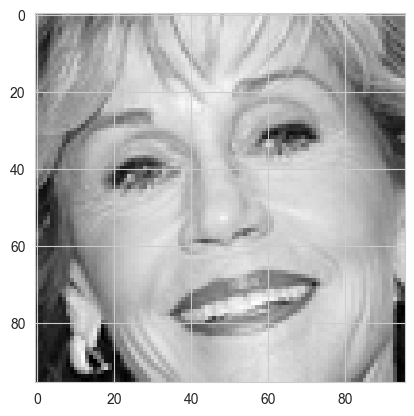

In [273]:
#checking work of new function 'convert_to_image_array'
idx = 1999 # random number, just for testing
image_array = convert_to_image_array(df['Image'].iloc[idx])

print(f"Shape of array: {image_array.shape}")
print(f"Data type: {image_array.dtype}")
plt.imshow(image_array, cmap='gray')
plt.show()

In [274]:
def display_image_with_landmarks_points(image_array, idx):
    # get landmarks point for concrete image
    landmarks_point = df.iloc[idx, :-1].values.astype('float32')

    # devide them into x and y coordinates
    x_coords = landmarks_point[0::2]
    y_coords = landmarks_point[1::2]

    # plot image with landmarks_points
    plt.figure(figsize=(6,6))
    plt.imshow(image_array, cmap='gray')
    plt.scatter(x_coords, y_coords, c='#47FF31', marker='o', s=15)
    plt.title(f"Face Index: {idx}")
    plt.show()

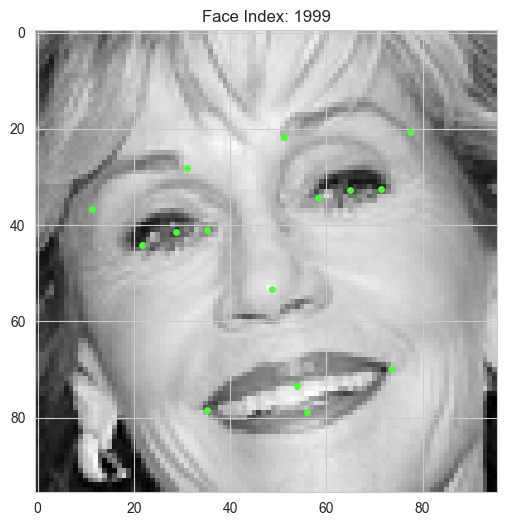

In [275]:
# checking work of new function 'display_image_with_landmarks_points'
display_image_with_landmarks_points(image_array, idx)

In [276]:
class FaceDataset(data.Dataset):
    def __init__(self, dataframe, transform=None, train=False):
        self.train = train

        #get images
        self.images = dataframe['Image'].values

        self.length = len(dataframe)

        self.transform = transform

        if not self.train:
            #get landmarks points
            self.landmarks_points = dataframe.iloc[:, :-1].values.astype('float32')
        else:
            self.landmarks_points = None

    def __getitem__(self, item):
        #work with image
        image_array = convert_to_image_array(self.images[item])
        image_array = image_array.reshape(96, 96, 1).astype('uint8')

        if self.transform:
            image_tensor = self.transform(image_array)
        else:
            # base transformation
            image_tensor = torch.from_numpy(image_array).permute(2, 0, 1).float() / 255.0

        if not self.train:
            #work with landmarks
            landmarks_tensor = torch.from_numpy(self.landmarks_points[item]) / 96.0

            return image_tensor, landmarks_tensor
        else:
            return image_tensor, item

    def __len__(self):
        return self.length

In [277]:
# checking work of new class 'FaceDataset'

# transformation
transforms = tfs.Compose([tfs.ToImage(), tfs.ToDtype(torch.float32,scale=True)])

d_train = FaceDataset(df, transform=transforms, train=False)

#get first example
img, points = d_train[0]
print(img.shape)
print(points.shape)

torch.Size([1, 96, 96])
torch.Size([30])


In [278]:
# dataloader
train_data = data.DataLoader(d_train, batch_size=32, shuffle=True)

In [279]:
#model
model = nn.Sequential(
    #input tensor (batch, 1, 96, 96)
    #1 - gray
    #96 x 96 pixels

    # first conv layer
    nn.Conv2d(in_channels=1,out_channels=32, kernel_size=3, padding="same"),
        #1 - count of channels (gray)
        #32 - count of filters
        #3 - size of each filter (3x3)
        #padding='same' - size of Feature Maps will be like image (96x96)
    nn.ReLU(),
    nn.MaxPool2d(2), # after this we will have tensor (batch, 32, 48, 48)

    # second conv layer
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same"),
    nn.ReLU(),
    nn.MaxPool2d(2), # after this we will have tensor (batch, 64, 24, 24)

    # third conv layer
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"),
    nn.ReLU(),
    nn.MaxPool2d(2), # after this we will have tensor (batch, 128, 12, 12)
    nn.Flatten(), # convert to 1d vector
    nn.Linear(18432, 128), # 18432 = 128 x 12 x 12
    nn.ReLU(),
    nn.Linear(128,30) # 30 - coordinates of 15 points (15*2)
)

In [280]:
# select place for calculating of tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device: \n", device)

device: 
 cpu


In [281]:
# optimizer
optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=0.001)

# loss function
loss_function = nn.MSELoss()

In [282]:
# transferred the model to device
model = model.to(device)

In [283]:
# training of model

epochs = 5
log_interval = 50

model.train()

for _e in range(epochs):
    running_loss = 0.0

    for batch_idx, (images, landmarks) in enumerate(train_data):
        images = images.to(device)
        landmarks = landmarks.to(device)

        predict = model(images)

        mask = landmarks != -1/96.0
        loss = torch.mean((predict[mask] - landmarks[mask])**2)
        #loss = loss_function(predict, landmarks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % log_interval == 0 and batch_idx > 0:
            current_loss = running_loss / log_interval
            print(f"Epoch [{_e+1}/{epochs}] | Batch [{batch_idx}/{len(train_data)}] | Loss: {current_loss}")
            running_loss = 0.0

    print(f"===> Epoch {_e+1} Complete. Model Saved.")

state = model.state_dict()
torch.save(state, 'faces.tar')

Epoch [1/5] | Batch [50/221] | Loss: 0.023677375395782293
Epoch [1/5] | Batch [100/221] | Loss: 0.001838001578580588
Epoch [1/5] | Batch [150/221] | Loss: 0.0018696841178461909
Epoch [1/5] | Batch [200/221] | Loss: 0.0019002912496216594
===> Epoch 1 Complete. Model Saved.
Epoch [2/5] | Batch [50/221] | Loss: 0.0022229771339334547
Epoch [2/5] | Batch [100/221] | Loss: 0.0018403015623334796
Epoch [2/5] | Batch [150/221] | Loss: 0.002370663327164948
Epoch [2/5] | Batch [200/221] | Loss: 0.0022526151896454395
===> Epoch 2 Complete. Model Saved.
Epoch [3/5] | Batch [50/221] | Loss: 0.0018852308997884392
Epoch [3/5] | Batch [100/221] | Loss: 0.0020834194193594157
Epoch [3/5] | Batch [150/221] | Loss: 0.0017475927155464887
Epoch [3/5] | Batch [200/221] | Loss: 0.002305582507979125
===> Epoch 3 Complete. Model Saved.
Epoch [4/5] | Batch [50/221] | Loss: 0.0018906234740279615
Epoch [4/5] | Batch [100/221] | Loss: 0.0018098387354984879
Epoch [4/5] | Batch [150/221] | Loss: 0.0019675397919490935


In [284]:
# testing

data_path = 'data/test.csv'

if os.path.exists(data_path):
    df_test = pd.read_csv(data_path)
    pd.set_option('display.max_columns', None)
    print(df_test.head())
else:
    print(f"File {data_path} does not exist. Please download it from Kaggle")



   ImageId                                              Image
0        1  182 183 182 182 180 180 176 169 156 137 124 10...
1        2  76 87 81 72 65 59 64 76 69 42 31 38 49 58 58 4...
2        3  177 176 174 170 169 169 168 166 166 166 161 14...
3        4  176 174 174 175 174 174 176 176 175 171 165 15...
4        5  50 47 44 101 144 149 120 58 48 42 35 35 37 39 ...


In [285]:
d_test = FaceDataset(df_test, transform=transforms, train=True)

#get first example
img, img_id = d_test[0]
print(img.shape)
print(img_id)

torch.Size([1, 96, 96])
0


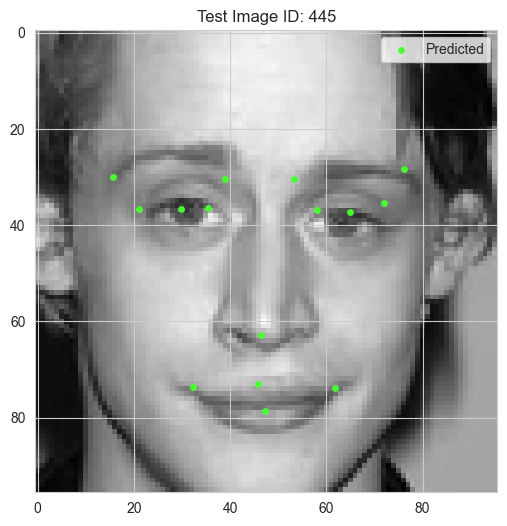

In [286]:
# stop training
model.eval()

with torch.no_grad():
    test_img, test_img_id = d_test[444]

    test_img = test_img.unsqueeze(0).to(device)

    prediction = model(test_img)

    #to array, multiply by 96, remove batch
    prediction_points = prediction.cpu().numpy().flatten() * 96.0

    #image from tensor to array
    display_image = test_img.cpu().squeeze().numpy()

    plt.figure(figsize=(6, 6))
    plt.imshow(display_image, cmap='gray')
    plt.scatter(prediction_points[0::2], prediction_points[1::2], c='#47FF31', marker='o', s=15, label='Predicted')
    plt.legend()
    plt.title(f"Test Image ID: {test_img_id + 1}")
    plt.show()

In [287]:
# test all data and make submission

test_loader = data.DataLoader(d_test, batch_size=32, shuffle=False)

model.eval()
all_preds = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        preds = model(images).cpu().numpy()
        all_preds.append(preds * 96.0)

all_preds = np.vstack(all_preds)

columns = df.columns[:-1].tolist()

feature_to_idx = {name: i for i, name in enumerate(columns)}

print("List of columns:", columns)
print("List of indexes:", feature_to_idx)



List of columns: ['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x', 'right_eye_center_y', 'left_eye_inner_corner_x', 'left_eye_inner_corner_y', 'left_eye_outer_corner_x', 'left_eye_outer_corner_y', 'right_eye_inner_corner_x', 'right_eye_inner_corner_y', 'right_eye_outer_corner_x', 'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x', 'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x', 'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x', 'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x', 'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y', 'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x', 'mouth_right_corner_y', 'mouth_center_top_lip_x', 'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x', 'mouth_center_bottom_lip_y']
List of indexes: {'left_eye_center_x': 0, 'left_eye_center_y': 1, 'right_eye_center_x': 2, 'right_eye_center_y': 3, 'left_eye_inner_corner_x': 4, 'left_eye_inner_corner_y': 5, 'left_eye_outer_corner_x': 6, 'left_eye_

In [288]:
data_path = 'data/IdLookupTable.csv'

if os.path.exists(data_path):
    lookup = pd.read_csv(data_path)
else:
    print(f"File {data_path} does not exist. Please download it from Kaggle")



In [289]:
# list for results
values = []

for i, row in lookup.iterrows():
    img_idx = int(row['ImageId']) - 1
    # name of concrete point
    feat_name = row['FeatureName']

    # index of pint
    feat_idx = feature_to_idx[feat_name]

    # get prediction
    val = all_preds[img_idx, feat_idx]

    values.append(val)

lookup['Location'] = values
lookup[['RowId', 'Location']].to_csv('submission.csv', index=False)